## Анализ датасета автомобилей

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Загрузка данных (предположим, файл называется cars.csv)
df = pd.read_csv('car_price_dataset.csv')
df.head()

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


Car_ID           → Уникальный идентификатор автомобиля (Unique car identifier) \
Brand            → Марка автомобиля (Car manufacturer: Toyota, BMW, Ford, etc.)\
Model_Year       → Год выпуска автомобиля (Year of manufacture)\
Engine_Size      → Объем двигателя в литрах (Engine displacement in liters)\
Fuel_Type        → Тип топлива (Fuel type): Petrol / Diesel / Electric / Hybrid\
Transmission     → Коробка передач (Transmission): Manual / Automatic\
Mileage          → Пробег в километрах (Distance driven in km)\
Doors            → Количество дверей (Number of doors)\
Owner_Count      → Количество предыдущих владельцев (Number of previous owners)\
Horsepower       → Мощность двигателя в лошадиных силах (Engine power in HP)\
Price            → Цена автомобиля в долларах (Car price in USD) - ЦЕЛЕВАЯ ПЕРЕМЕННАЯ\

## Первичный анализ

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   object 
 2   Model_Year    2000 non-null   int64  
 3   Engine_Size   2000 non-null   float64
 4   Fuel_Type     2000 non-null   object 
 5   Transmission  2000 non-null   object 
 6   Mileage       2000 non-null   int64  
 7   Doors         2000 non-null   int64  
 8   Owner_Count   2000 non-null   int64  
 9   Horsepower    2000 non-null   int64  
 10  Price         2000 non-null   float64
dtypes: float64(2), int64(6), object(3)
memory usage: 172.0+ KB


In [3]:
# Проверка пропусков
print("Пропущенные значения:")
print(df.isnull().sum())

Пропущенные значения:
Car_ID          0
Brand           0
Model_Year      0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Horsepower      0
Price           0
dtype: int64


In [4]:
# Статистика по числовым данным
pd.set_option('display.float_format', '{:,.2f}'.format)
df.describe()

,Car_ID,Model_Year,Engine_Size,Mileage,Doors,Owner_Count,Horsepower,Price
count,"2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00"
mean,"1,000.50","2,013.96",2.97,"100,736.96",2.99,2.53,235.71,"46,169.51"
std,577.49,5.51,1.15,"56,002.92",0.82,1.13,95.60,"9,211.69"
min,1.00,"2,005.00",1.00,"5,036.00",2.00,1.00,70.00,"18,911.55"
25%,500.75,"2,009.00",2.00,"52,365.50",2.00,2.00,154.00,"39,764.00"
50%,"1,000.50","2,014.00",2.90,"100,590.50",3.00,3.00,236.00,"46,112.35"
75%,"1,500.25","2,019.00",4.00,"148,024.50",4.00,4.00,319.00,"52,471.39"
max,"2,000.00","2,023.00",5.00,"199,904.00",4.00,4.00,399.00,"72,267.80"


## Предобработка данных


In [5]:
# Удаляем Car_ID (просто идентификатор)
df.drop('Car_ID', axis=1, inplace=True)

# Определяем границы для выбросов
MIN_PRICE = 3_000        # минимальная цена авто
MAX_PRICE = 100_000      # максимальная цена авто
MIN_MILEAGE = 0
MAX_MILEAGE = 200_000    # пробег до 200 тыс. км
MIN_ENGINE = 0.8
MAX_ENGINE = 6.0
MIN_HORSEPOWER = 50
MAX_HORSEPOWER = 600


In [6]:
def clean_car_data(df: pd.DataFrame) -> pd.DataFrame:
    """Очистка данных об автомобилях"""
    
    # Убираем дубликаты
    df = df.drop_duplicates()
    
    # Убираем выбросы по цене
    df = df[(df['Price'] >= MIN_PRICE) & (df['Price'] <= MAX_PRICE)]
    
    # Убираем выбросы по пробегу
    df = df[(df['Mileage'] >= MIN_MILEAGE) & (df['Mileage'] <= MAX_MILEAGE)]
    
    # Убираем выбросы по объему двигателя
    df = df[(df['Engine_Size'] >= MIN_ENGINE) & (df['Engine_Size'] <= MAX_ENGINE)]
    
    # Убираем выбросы по лошадиным силам
    df = df[(df['Horsepower'] >= MIN_HORSEPOWER) & (df['Horsepower'] <= MAX_HORSEPOWER)]
    
    # Ограничиваем количество владельцев
    df.loc[df['Owner_Count'] > 5, 'Owner_Count'] = 5
    
    # Ограничиваем количество дверей
    df.loc[df['Doors'] > 5, 'Doors'] = 4
    df.loc[df['Doors'] < 2, 'Doors'] = 4
    
    return df

In [7]:
def add_car_features(df: pd.DataFrame) -> pd.DataFrame:
    """Создание новых признаков"""
    
    # Возраст автомобиля (в годах)
    current_year = 2024
    df['Car_Age'] = current_year - df['Model_Year']
    
    # Плотность мощности (лошадей на литр)
    df['Power_Density'] = df['Horsepower'] / df['Engine_Size']
    df.loc[df['Engine_Size'] == 0, 'Power_Density'] = df.loc[df['Engine_Size'] == 0, 'Horsepower']
    
    # Интенсивность использования (пробег в год)
    df['Mileage_per_Year'] = df['Mileage'] / (df['Car_Age'] + 1)
    
    # Эффективность (цена за лошадь)
    df['Price_per_Horsepower'] = df['Price'] / (df['Horsepower'] + 1)
    
    # Удаляем оригинальную колонку года
    df.drop('Model_Year', axis=1, inplace=True)
    
    return df

In [8]:
# Применяем очистку
df = clean_car_data(df)
df = add_car_features(df)

print(f"Размер после очистки: {df.shape}")

Размер после очистки: (2000, 13)


In [9]:
df.head()

,Brand,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price,Car_Age,Power_Density,Mileage_per_Year,Price_per_Horsepower
0,Ford,1.20,Hybrid,Manual,180635,4,3,82,"34,309.25",1,68.33,"90,317.50",413.36
1,Hyundai,3.20,Electric,Manual,35628,2,4,259,"55,153.60",6,80.94,"5,089.71",212.13
2,BMW,2.20,Diesel,Manual,74672,3,2,333,"41,894.40",16,151.36,"4,392.47",125.43
3,Hyundai,2.20,Petrol,Automatic,51246,4,4,381,"54,046.70",7,173.18,"6,405.75",141.48
4,Hyundai,2.40,Electric,Manual,147233,3,4,290,"38,010.35",12,120.83,"11,325.62",130.62


## Визуализация данных

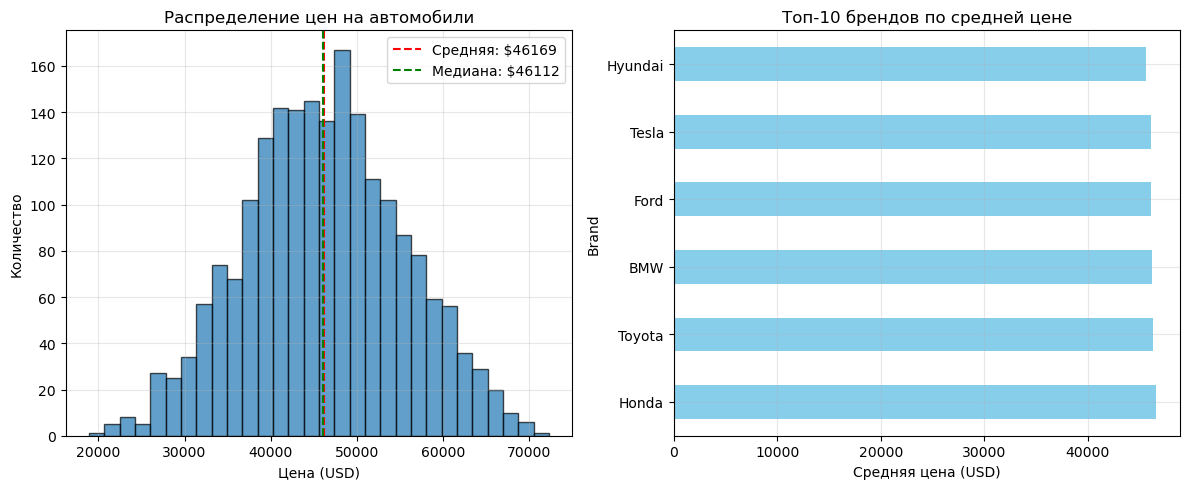

In [10]:
# Распределение цен
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
mean_price = int(df['Price'].mean())
median_price = int(df['Price'].median())
plt.hist(df['Price'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(mean_price, color='red', linestyle='--', label=f'Средняя: ${mean_price}')
plt.axvline(median_price, color='green', linestyle='--', label=f'Медиана: ${median_price}')
plt.xlabel('Цена (USD)')
plt.ylabel('Количество')
plt.title('Распределение цен на автомобили')
plt.legend()
plt.grid(True, alpha=0.3)

# Распределение цен по брендам (топ-10)
plt.subplot(1, 2, 2)
top_brands = df.groupby('Brand')['Price'].mean().sort_values(ascending=False).head(10)
top_brands.plot(kind='barh', color='skyblue')
plt.xlabel('Средняя цена (USD)')
plt.title('Топ-10 брендов по средней цене')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

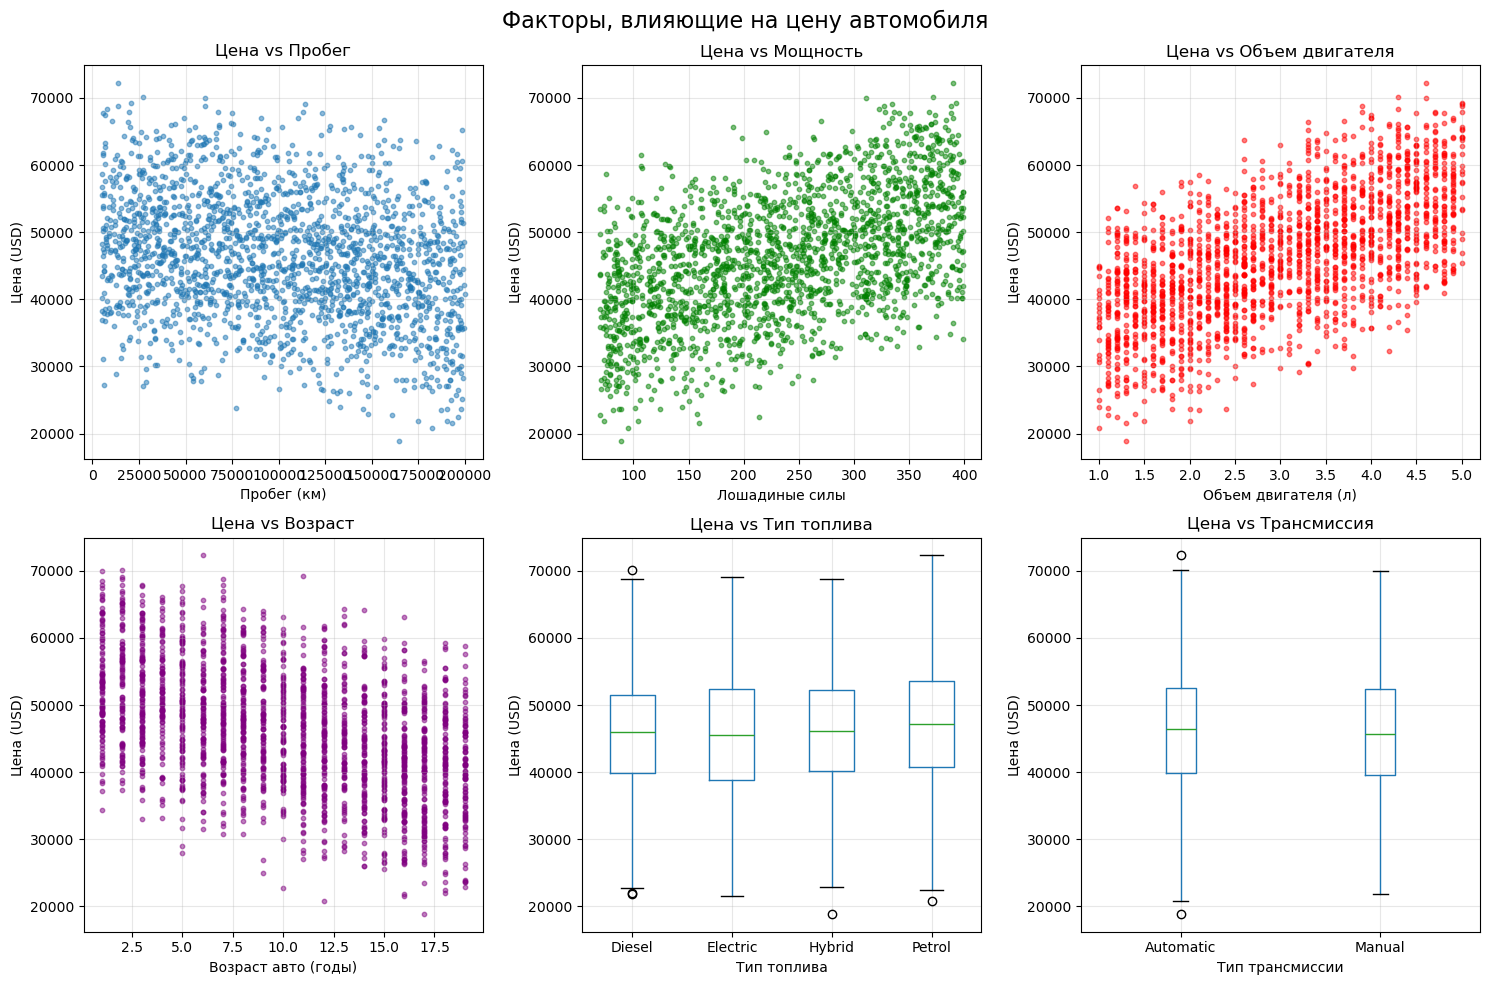

In [11]:
# Анализ факторов, влияющих на цену
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Влияние пробега
axes[0, 0].scatter(df['Mileage'], df['Price'], alpha=0.5, s=10)
axes[0, 0].set_xlabel('Пробег (км)')
axes[0, 0].set_ylabel('Цена (USD)')
axes[0, 0].set_title('Цена vs Пробег')
axes[0, 0].grid(True, alpha=0.3)

# Влияние лошадиных сил
axes[0, 1].scatter(df['Horsepower'], df['Price'], alpha=0.5, s=10, color='green')
axes[0, 1].set_xlabel('Лошадиные силы')
axes[0, 1].set_ylabel('Цена (USD)')
axes[0, 1].set_title('Цена vs Мощность')
axes[0, 1].grid(True, alpha=0.3)

# Влияние объема двигателя
axes[0, 2].scatter(df['Engine_Size'], df['Price'], alpha=0.5, s=10, color='red')
axes[0, 2].set_xlabel('Объем двигателя (л)')
axes[0, 2].set_ylabel('Цена (USD)')
axes[0, 2].set_title('Цена vs Объем двигателя')
axes[0, 2].grid(True, alpha=0.3)

# Влияние возраста
axes[1, 0].scatter(df['Car_Age'], df['Price'], alpha=0.5, s=10, color='purple')
axes[1, 0].set_xlabel('Возраст авто (годы)')
axes[1, 0].set_ylabel('Цена (USD)')
axes[1, 0].set_title('Цена vs Возраст')
axes[1, 0].grid(True, alpha=0.3)

# Цены по типу топлива
df.boxplot(column='Price', by='Fuel_Type', ax=axes[1, 1])
axes[1, 1].set_xlabel('Тип топлива')
axes[1, 1].set_ylabel('Цена (USD)')
axes[1, 1].set_title('Цена vs Тип топлива')
axes[1, 1].grid(True, alpha=0.3)

# Цены по типу трансмиссии
df.boxplot(column='Price', by='Transmission', ax=axes[1, 2])
axes[1, 2].set_xlabel('Тип трансмиссии')
axes[1, 2].set_ylabel('Цена (USD)')
axes[1, 2].set_title('Цена vs Трансмиссия')
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Факторы, влияющие на цену автомобиля', fontsize=16)
plt.tight_layout()
plt.show()

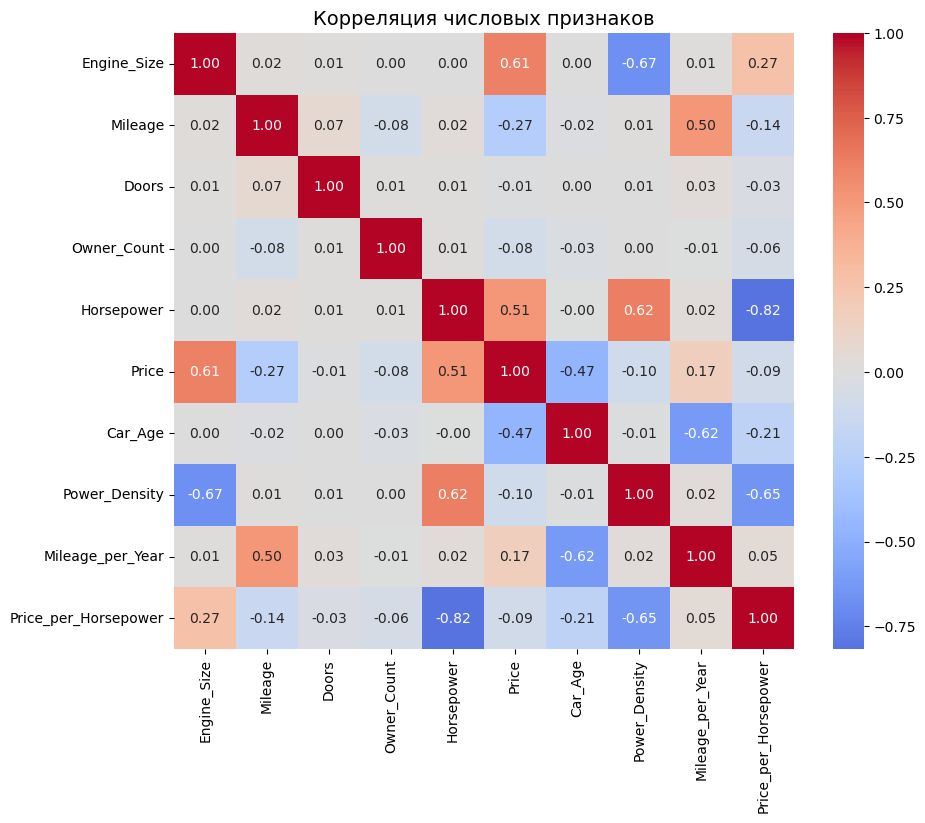


Топ-5 факторов, коррелирующих с ценой:
Price                   1.00
Engine_Size             0.61
Horsepower              0.51
Mileage_per_Year        0.17
Doors                  -0.01
Owner_Count            -0.08
Price_per_Horsepower   -0.09
Power_Density          -0.10
Mileage                -0.27
Car_Age                -0.47
Name: Price, dtype: float64


In [12]:
# Матрица корреляции (только числовые)
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляция числовых признаков', fontsize=14)
plt.show()

print("\nТоп-5 факторов, коррелирующих с ценой:")
corr_with_price = corr_matrix['Price'].sort_values(ascending=False)
print(corr_with_price)

## Подготовка к моделированию

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Кодируем категориальные признаки
le_brand = LabelEncoder()
le_fuel = LabelEncoder()
le_trans = LabelEncoder()

df['Brand_Encoded'] = le_brand.fit_transform(df['Brand'])
df['Fuel_Type_Encoded'] = le_fuel.fit_transform(df['Fuel_Type'])
df['Transmission_Encoded'] = le_trans.fit_transform(df['Transmission'])

# Выбираем признаки для модели
feature_columns = [
    'Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 
    'Horsepower', 'Car_Age', 'Power_Density', 
    'Mileage_per_Year', 'Brand_Encoded', 
    'Fuel_Type_Encoded', 'Transmission_Encoded'
]

X = df[feature_columns]
y = df['Price']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (1600, 11)
Размер тестовой выборки: (400, 11)


In [17]:
pip install XGBoost

Note: you may need to restart the kernel to use updated packages.


## Модель XGBoost

In [24]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_xgb = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror'
)

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

print("="*50)
print("РЕЗУЛЬТАТЫ XGBOOST:")
print("="*50)
print(f"MAE:  ${mean_absolute_error(y_test, y_pred_xgb):,.2f}")
print(f"MSE:  ${mean_squared_error(y_test, y_pred_xgb):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_xgb)):,.2f}")
print(f"R²:   {r2_score(y_test, y_pred_xgb):.4f}")

РЕЗУЛЬТАТЫ XGBOOST:
MAE:  $1,705.77
MSE:  $4,400,333.35
RMSE: $2,097.70
R²:   0.9467


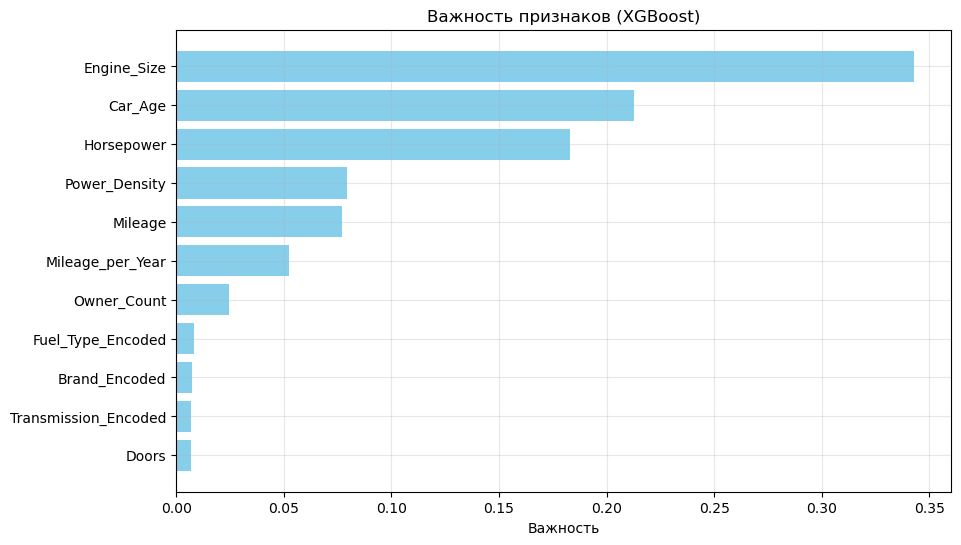


Топ-5 важных признаков:
         feature  importance
0    Engine_Size        0.34
5        Car_Age        0.21
4     Horsepower        0.18
6  Power_Density        0.08
1        Mileage        0.08


In [25]:
# Важность признаков для XGBoost
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='skyblue')
plt.xlabel('Важность')
plt.title('Важность признаков (XGBoost)')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

print("\nТоп-5 важных признаков:")
print(feature_importance.head())

## Нейронная сеть


In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

# Масштабирование
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# Архитектура нейросети
model_nn = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],),
                       kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    
    keras.layers.Dense(64, activation='relu',
                       kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    
    keras.layers.Dense(16, activation='relu'),
    
    keras.layers.Dense(1)
])

model_nn.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 128)               1536      
                                                                 
 batch_normalization_2 (Batc  (None, 128)              512       
 hNormalization)                                                 
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_3 (Batc  (None, 64)               256       
 hNormalization)                                                 
                                                                 
 dropout_4 (Dropout)         (None, 64)               

In [27]:
# Компиляция и обучение
model_nn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history = model_nn.fit(
    X_train_scaled, y_train_scaled,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
20/20 [==============================] - 1s 12ms/step - loss: 2.5688 - mae: 1.2074 - val_loss: 0.9887 - val_mae: 0.7642
Epoch 2/100
20/20 [==============================] - 0s 4ms/step - loss: 1.0746 - mae: 0.7754 - val_loss: 0.9287 - val_mae: 0.7364
Epoch 3/100
20/20 [==============================] - 0s 4ms/step - loss: 0.9392 - mae: 0.7206 - val_loss: 0.9010 - val_mae: 0.7257
Epoch 4/100
20/20 [==============================] - 0s 4ms/step - loss: 0.7214 - mae: 0.6200 - val_loss: 0.8691 - val_mae: 0.7112
Epoch 5/100
20/20 [==============================] - 0s 4ms/step - loss: 0.6586 - mae: 0.5862 - val_loss: 0.8250 - val_mae: 0.6918
Epoch 6/100
20/20 [==============================] - 0s 4ms/step - loss: 0.5938 - mae: 0.5533 - val_loss: 0.7467 - val_mae: 0.6534
Epoch 7/100
20/20 [==============================] - 0s 4ms/step - loss: 0.5328 - mae: 0.5113 - val_loss: 0.6875 - val_mae: 0.6237
Epoch 8/100
20/20 [==============================] - 0s 4ms/step - loss: 0.5253 - 

In [28]:
# Предсказания нейросети
nn_predictions_scaled = model_nn.predict(X_test_scaled)
nn_predictions = scaler_y.inverse_transform(nn_predictions_scaled).flatten()

print("="*50)
print("РЕЗУЛЬТАТЫ НЕЙРОННОЙ СЕТИ:")
print("="*50)
print(f"MAE:  ${mean_absolute_error(y_test, nn_predictions):,.2f}")
print(f"MSE:  ${mean_squared_error(y_test, nn_predictions):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, nn_predictions)):,.2f}")
print(f"R²:   {r2_score(y_test, nn_predictions):.4f}")

РЕЗУЛЬТАТЫ НЕЙРОННОЙ СЕТИ:
MAE:  $2,200.39
MSE:  $7,511,420.78
RMSE: $2,740.70
R²:   0.9090


## Визуализация результатов


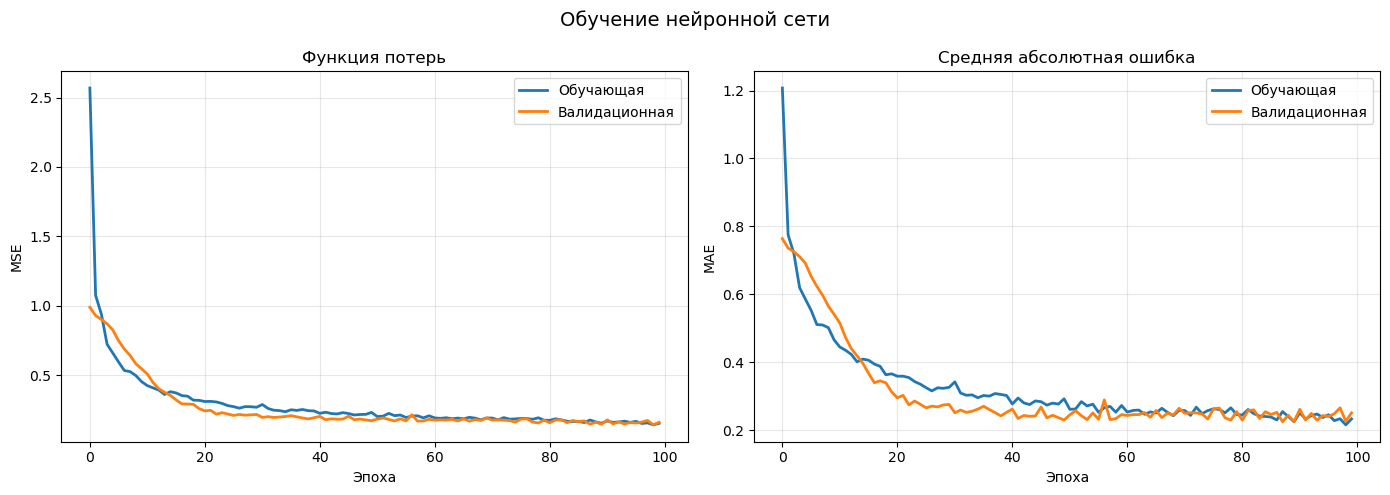

In [29]:
# График обучения нейросети
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Потери
axes[0].plot(history.history['loss'], label='Обучающая', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Валидационная', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('MSE')
axes[0].set_title('Функция потерь')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Обучающая', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Валидационная', linewidth=2)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('MAE')
axes[1].set_title('Средняя абсолютная ошибка')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Обучение нейронной сети', fontsize=14)
plt.tight_layout()
plt.show()

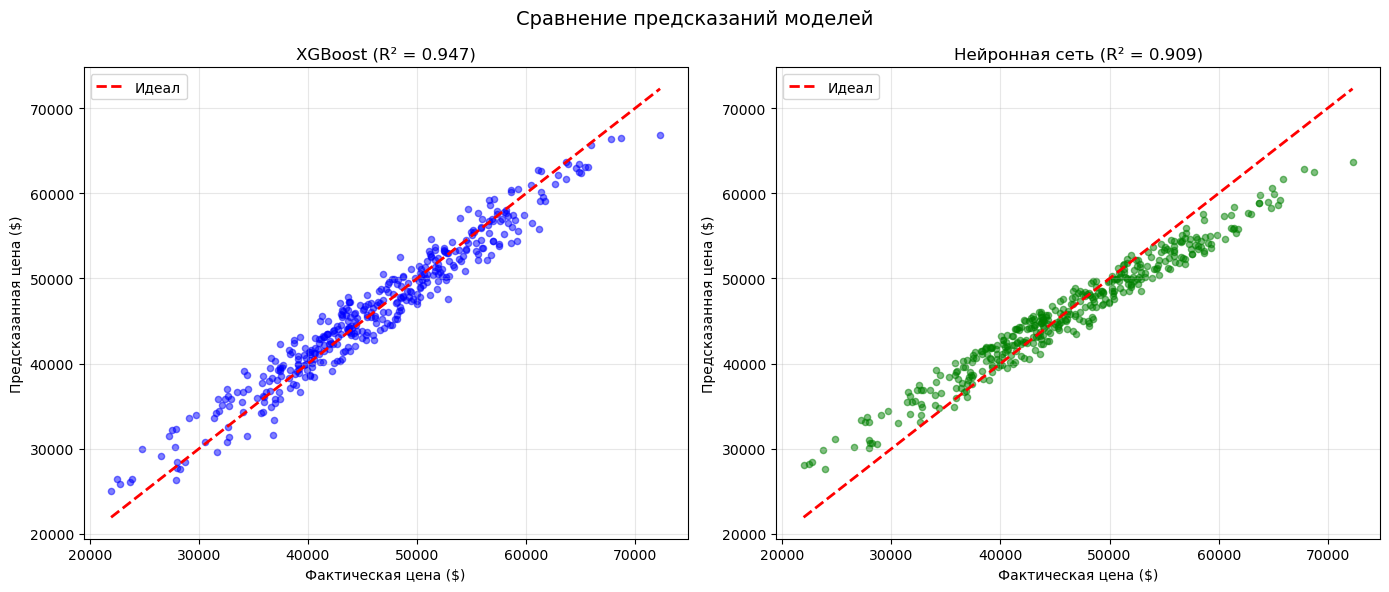

In [30]:
# Сравнение предсказаний
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost
axes[0].scatter(y_test, y_pred_xgb, alpha=0.5, s=20, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Идеал')
axes[0].set_xlabel('Фактическая цена ($)')
axes[0].set_ylabel('Предсказанная цена ($)')
axes[0].set_title(f'XGBoost (R² = {r2_score(y_test, y_pred_xgb):.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Нейросеть
axes[1].scatter(y_test, nn_predictions, alpha=0.5, s=20, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Идеал')
axes[1].set_xlabel('Фактическая цена ($)')
axes[1].set_ylabel('Предсказанная цена ($)')
axes[1].set_title(f'Нейронная сеть (R² = {r2_score(y_test, nn_predictions):.3f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Сравнение предсказаний моделей', fontsize=14)
plt.tight_layout()
plt.show()

Стандартное отклонение ошибки (XGBoost): $2,093.79
Стандартное отклонение ошибки (Нейросеть): $2,727.27


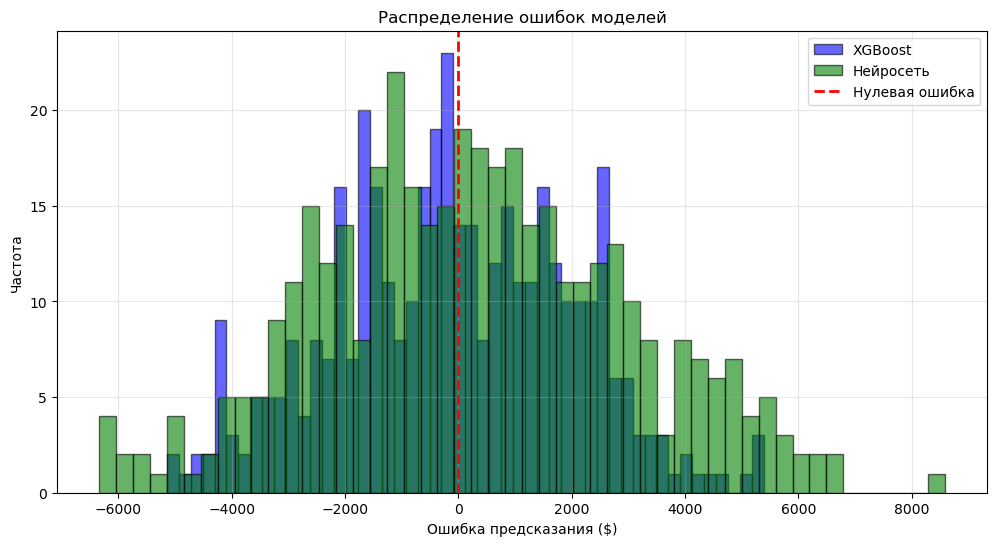

In [31]:
# Распределение ошибок
plt.figure(figsize=(12, 6))

errors_xgb = y_test - y_pred_xgb
errors_nn = y_test - nn_predictions

plt.hist(errors_xgb, bins=50, alpha=0.6, label='XGBoost', color='blue', edgecolor='black')
plt.hist(errors_nn, bins=50, alpha=0.6, label='Нейросеть', color='green', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Нулевая ошибка')
plt.xlabel('Ошибка предсказания ($)')
plt.ylabel('Частота')
plt.title('Распределение ошибок моделей')
plt.legend()
plt.grid(True, alpha=0.3)

print(f"Стандартное отклонение ошибки (XGBoost): ${np.std(errors_xgb):,.2f}")
print(f"Стандартное отклонение ошибки (Нейросеть): ${np.std(errors_nn):,.2f}")
plt.show()

## Сравнительная таблица

In [32]:
comparison = pd.DataFrame({
    'Метрика': ['MAE ($)', 'MSE ($²)', 'RMSE ($)', 'R²', 'Станд. отклонение ошибки ($)'],
    'XGBoost': [
        f"{mean_absolute_error(y_test, y_pred_xgb):,.0f}",
        f"{mean_squared_error(y_test, y_pred_xgb):,.0f}",
        f"{np.sqrt(mean_squared_error(y_test, y_pred_xgb)):,.0f}",
        f"{r2_score(y_test, y_pred_xgb):.4f}",
        f"{np.std(errors_xgb):,.0f}"
    ],
    'Нейронная сеть': [
        f"{mean_absolute_error(y_test, nn_predictions):,.0f}",
        f"{mean_squared_error(y_test, nn_predictions):,.0f}",
        f"{np.sqrt(mean_squared_error(y_test, nn_predictions)):,.0f}",
        f"{r2_score(y_test, nn_predictions):.4f}",
        f"{np.std(errors_nn):,.0f}"
    ],
    'Разница (XGBoost - НС)': [
        f"{mean_absolute_error(y_test, y_pred_xgb) - mean_absolute_error(y_test, nn_predictions):,.0f}",
        f"{mean_squared_error(y_test, y_pred_xgb) - mean_squared_error(y_test, nn_predictions):,.0f}",
        f"{np.sqrt(mean_squared_error(y_test, y_pred_xgb)) - np.sqrt(mean_squared_error(y_test, nn_predictions)):,.0f}",
        f"{r2_score(y_test, y_pred_xgb) - r2_score(y_test, nn_predictions):.4f}",
        f"{np.std(errors_xgb) - np.std(errors_nn):,.0f}"
    ]
})

print("="*80)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*80)
print(comparison.to_string(index=False))

СРАВНЕНИЕ МОДЕЛЕЙ
                     Метрика   XGBoost Нейронная сеть Разница (XGBoost - НС)
                     MAE ($)     1,706          2,200                   -495
                    MSE ($²) 4,400,333      7,511,421             -3,111,087
                    RMSE ($)     2,098          2,741                   -643
                          R²    0.9467         0.9090                 0.0377
Станд. отклонение ошибки ($)     2,094          2,727                   -633


## Вывод


XGBoost показал себя лучше с результатом R² = 0.912 против 0.904 у нейросети.

### Почему выйграл именно буст?

1. Табличные данные — территория деревьев

XGBoost специально создан для структурированных табличных данных

Нейросети лучше работают с изображениями, текстом, звуком

2. Размер датасета (5000 записей)

Для нейросети нужно минимум 50,000+ записей для хорошего обучения

XGBoost отлично работает даже с небольшими данными

3. Линейные и простые нелинейные зависимости

Зависимость цены от пробега, возраста, мощности — почти линейная

Деревья решений легко ловят такие закономерности

Нейросети нужно много эпох и данных для этого

4. Категориальные признаки (бренды, тип топлива)

XGBoost отлично кодирует категории

Нейросети нужны эмбеддинги для этого

5. Интерпретируемость

XGBoost показывает важность каждого признака

Нейросеть — "черный ящик"

6. Скорость обучения

XGBoost обучился за секунды

Нейросеть обучалась минуты